In [44]:
import numpy as np
from dataclasses import dataclass
from typing import Optional
try:
    from scipy.integrate import quad
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False
from astropy import units as u
from astropy import constants as const

C_KMS = const.c.to(u.km/u.s).value

@dataclass
class CosmoParams:
    H0: float = 70.0            # [km/s/Mpc]
    Om0: float = 0.3            # Ω_m
    Ok0: float = 0.0            # Ω_k
    Or0: float = 0.0            # Ω_r (可忽略时设 0)
    # 暗能量状态方程：二选一
    w: Optional[float] = None      # 常数 w
    w0: float = -1.0            # CPL: w(a)=w0+wa(1-a)
    wa: float = 0.0

    def Ode0(self) -> float:
        return 1.0 - self.Om0 - self.Ok0 - self.Or0

def _rho_de_factor(z: float, cp: CosmoParams) -> float:
    """ρ_DE(z)/ρ_DE(0) 的无量纲演化因子。"""
    if cp.w is not None:  # 常数 w
        return (1.0 + z)**(3.0 * (1.0 + cp.w))
    # CPL: w(a)=w0+wa(1-a) => ρ_DE ∝ (1+z)^{3(1+w0+wa)} exp[-3 wa z/(1+z)]
    return (1.0 + z)**(3.0 * (1.0 + cp.w0 + cp.wa)) * np.exp(-3.0 * cp.wa * z / (1.0 + z))

def Ez(z: float, cp: CosmoParams) -> float:
    """E(z) = H(z)/H0."""
    de = cp.Ode0() * _rho_de_factor(z, cp)
    return np.sqrt(cp.Om0 * (1.0 + z)**3 + cp.Or0 * (1.0 + z)**4 + cp.Ok0 * (1.0 + z)**2 + de)

def _chi_quad(z: float, cp: CosmoParams) -> float:
    """无量纲共动径向距离 χ(z) = ∫_0^z dz'/E(z')."""
    if _HAS_SCIPY:
        val, _ = quad(lambda zp: 1.0 / Ez(zp, cp), 0.0, float(z), epsrel=1e-8, epsabs=0.0, limit=256)
        return val
    # 简单梯形积分后备方案
    zgrid = np.linspace(0.0, float(z), 4097)
    return np.trapz(1.0 / np.vectorize(Ez)(zgrid, cp), zgrid)

def _Sk(x: float, Ok0: float) -> float:
    """曲率函数 S_k(x)。注意这里的 x 是 √|Ω_k| χ。"""
    if abs(Ok0) < 1e-12:
        return x
    if Ok0 > 0.0:  # open, sinh
        return np.sinh(x)
    else:          # closed, sin
        return np.sin(x)

def D_M(z: float, cp: CosmoParams) -> float:
    """横向共动距离 D_M(z) [Mpc]."""
    chi = _chi_quad(z, cp)
    if abs(cp.Ok0) < 1e-12:
        return (C_KMS / cp.H0) * chi
    sqrtOk = np.sqrt(abs(cp.Ok0))
    return (C_KMS / cp.H0) * _Sk(sqrtOk * chi, cp.Ok0) / sqrtOk

def D_A(z: float, cp: CosmoParams) -> float:
    """角径距 D_A(0→z) [Mpc]."""
    return D_M(z, cp) / (1.0 + z)

def D_A12(z1: float, z2: float, cp: CosmoParams) -> float:
    """两红移间角径距 D_A(z1→z2) [Mpc], 需 z2>z1。"""
    if not (z2 > z1):
        raise ValueError("Require z2 > z1 for D_A12.")
    chi1 = _chi_quad(z1, cp)
    chi2 = _chi_quad(z2, cp)
    dchi = chi2 - chi1
    if abs(cp.Ok0) < 1e-12:
        DM12 = (C_KMS / cp.H0) * dchi
    else:
        sqrtOk = np.sqrt(abs(cp.Ok0))
        DM12 = (C_KMS / cp.H0) * _Sk(sqrtOk * dchi, cp.Ok0) / sqrtOk
    return DM12 / (1.0 + z2)

# ---- 封装常用距离 ----
def Dl(zl: float, cp: CosmoParams) -> float: return D_A(zl, cp)
def Ds(zs: float, cp: CosmoParams) -> float: return D_A(zs, cp)
def Dls(zl: float, zs: float, cp: CosmoParams) -> float: return D_A12(zl, zs, cp)

# =========================
# 1) 星系–星系透镜：R = Ds / Dls
# =========================
def galaxy_lens_distance_ratio(zl: float, zs: float, *,
                               H0: float, omega_m: float,
                               omega_k: float = 0.0, omega_r: float = 0.0,
                               w: Optional[float] = None, w0: float = -1.0, wa: float = 0.0) -> float:
    """
    返回 R = D_s / D_ls （无量纲），仅含宇宙学部分。
    注：真实建模还需乘以结构因子 F(γ, β_ani, θ_ap/θ_E) 才能与(θ_E, σ_ap)组合。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    return Ds(zs, cp) / Dls(zl, zs, cp)

# =========================
# 2) 时延 AGN：D_dt = (1+zl) Dl Ds / Dls
# =========================
def time_delay_distance(zl: float, zs: float, *,
                        H0: float, omega_m: float,
                        omega_k: float = 0.0, omega_r: float = 0.0,
                        w: Optional[float] = None, w0: float = -1.0, wa: float = 0.0) -> float:
    """
    返回时延距离 D_Δt [Mpc]： (1+zl) * Dl * Ds / Dls
    注意：观测上 D_Δt 还会被外会聚 κ_ext 等效缩放，建模需单独处理。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    return (1.0 + zl) * Dl(zl, cp) * Ds(zs, cp) / Dls(zl, zs, cp)

# =========================
# 3) 双源透镜：β_DSP = (D_ls2/D_s2) / (D_ls1/D_s1)
# =========================
def double_source_beta(zl: float, zs1: float, zs2: float, *,
                       H0: float, omega_m: float,
                       omega_k: float = 0.0, omega_r: float = 0.0,
                       w: Optional[float] = None, w0: float = -1.0, wa: float = 0.0) -> float:
    """
    返回双源透镜的宇宙学量 β_DSP （无量纲）。
    要求 zl < zs1 < zs2。
    """
    if not (zl < zs1 < zs2):
        raise ValueError("Require zl < zs1 < zs2 for double-source lensing.")
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    num = Dls(zl, zs2, cp) / Ds(zs2, cp)
    den = Dls(zl, zs1, cp) / Ds(zs1, cp)
    return num / den

import numpy as np

def _as_float(x):
    # 确保传给积分器的是标量 float
    return float(np.asarray(x))

def galaxy_lens_distance_ratio_vec(
    zl, zs, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0
):
    """
    向量化版本：返回 R = Ds/Dls（与 zl、zs 广播后的形状一致）。
    不满足 zs>zl 的元素返回 np.nan。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    zlA, zsA = np.broadcast_arrays(np.asarray(zl, float), np.asarray(zs, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, zsA, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['writeonly']])
    for zl_i, zs_i, o in it:
        zl_f, zs_f = _as_float(zl_i), _as_float(zs_i)
        if zs_f <= zl_f:
            o[...] = np.nan
        else:
            # o[...] = Ds(zs_f, cp) / Dls(zl_f, zs_f, cp)
            o[...] = Dls(zl_f, zs_f, cp) / Ds(zs_f, cp)
    return out

def time_delay_distance_vec(
    zl, zs, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0
):
    """
    向量化版本：返回 D_dt [Mpc] = (1+zl) * Dl * Ds / Dls。
    不满足 zs>zl 的元素返回 np.nan。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    zlA, zsA = np.broadcast_arrays(np.asarray(zl, float), np.asarray(zs, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, zsA, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['writeonly']])
    for zl_i, zs_i, o in it:
        zl_f, zs_f = _as_float(zl_i), _as_float(zs_i)
        if zs_f <= zl_f:
            o[...] = np.nan
        else:
            o[...] = (1.0 + zl_f) * Dl(zl_f, cp) * Ds(zs_f, cp) / Dls(zl_f, zs_f, cp)
    return out

def double_source_beta_vec(
    zl, zs1, zs2, *, H0, omega_m, omega_k=0.0, omega_r=0.0,
    w=None, w0=-1.0, wa=0.0
):
    """
    向量化版本：返回 β_DSP = (D_ls2/D_s2)/(D_ls1/D_s1)。
    仅当 zl < zs1 < zs2 时有效，否则该元素 np.nan。
    """
    cp = CosmoParams(H0=H0, Om0=omega_m, Ok0=omega_k, Or0=omega_r, w=w, w0=w0, wa=wa)
    zlA, z1A, z2A = np.broadcast_arrays(np.asarray(zl, float),
                                        np.asarray(zs1, float),
                                        np.asarray(zs2, float))
    out = np.empty_like(zlA, dtype=float)
    it = np.nditer([zlA, z1A, z2A, out], flags=['multi_index'],
                   op_flags=[['readonly'], ['readonly'], ['readonly'], ['writeonly']])
    for zl_i, z1_i, z2_i, o in it:
        zl_f, z1_f, z2_f = _as_float(zl_i), _as_float(z1_i), _as_float(z2_i)
        if not (zl_f < z1_f < z2_f):
            o[...] = np.nan
        else:
            num = Dls(zl_f, z2_f, cp) / Ds(z2_f, cp)
            den = Dls(zl_f, z1_f, cp) / Ds(z1_f, cp)
            o[...] = num / den
    return out



In [48]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List

# ---------- 1) 标量 β_DSP ----------
def beta_scalar(zl: float, zs1: float, zs2: float, cosmo: Dict) -> float:
    """β_DSP(zl; zs1, zs2) = (D_ls2/D_s2) / (D_ls1/D_s1)."""
    return double_source_beta(float(zl), float(zs1), float(zs2), **cosmo)

# ---------- 2) 数值导数：∂ ln β_DSP / ∂ p ----------
def dlnbeta_dp(zl: float, zs1: float, zs2: float, cosmo: Dict, p: str,
               eps_rel: float = 1e-5, eps_abs: float = 1e-5) -> float:
    """
    对参数 p 求 ∂ ln β_DSP 的数值导数。
    - 对可能为 0/有号的参数（w0, wa, omega_k）用绝对步长；其余用相对步长。
    - 注意 β_DSP 与 H0 完全相消；若 p='H0'，导数应≈0（数值误差级）。
    """
    base = beta_scalar(zl, zs1, zs2, cosmo)
    if not np.isfinite(base) or base <= 0:
        return np.nan

    val = cosmo.get(p, None)
    if (val is None) or (abs(val) < 1e-12) or (p in ["w0", "wa", "omega_k"]):
        dp = eps_abs if p not in ["omega_m", "H0"] else max(eps_abs, 1e-6)
        p_minus = (val - dp) if (val is not None) else -dp
        p_plus  = (val + dp) if (val is not None) else  dp
    else:
        dp = abs(val) * eps_rel
        p_minus, p_plus = val - dp, val + dp

    # 物理边界
    if p == "omega_m":
        # p_minus = max(1e-6, p_minus); p_plus = max(1e-6, p_plus)
        p_minus = np.clip(p_minus, -0.5, 0.5); p_plus = np.clip(p_plus, -0.5, 0.5)
    if p == "omega_k":
        p_minus = np.clip(p_minus, -0.5, 0.5); p_plus = np.clip(p_plus, -0.5, 0.5)
    if p == "H0":
        p_minus = max(1.0, p_minus); p_plus = max(2.0, p_plus)

    cosmo_m = cosmo.copy();  cosmo_m[p]  = p_minus
    cosmo_p = cosmo.copy();  cosmo_p[p]  = p_plus

    bm = beta_scalar(zl, zs1, zs2, cosmo_m)
    bp = beta_scalar(zl, zs1, zs2, cosmo_p)
    if (bm <= 0) or (bp <= 0) or (not np.isfinite(bm)) or (not np.isfinite(bp)):
        return np.nan

    return float((np.log(bp) - np.log(bm)) / (p_plus - p_minus))

# ---------- 3) Fisher：单点 ----------
def fisher_single_beta(zl: float, zs1: float, zs2: float,
                       cosmo: Dict, params: List[str], sigma_frac: float) -> np.ndarray:
    """
    返回 β_DSP 的单点 Fisher（len(params) × len(params)）
    sigma_frac: β 的相对（分数）观测误差。
    """
    J = np.array([dlnbeta_dp(zl, zs1, zs2, cosmo, p) for p in params], dtype=float)
    if not np.all(np.isfinite(J)):
        return np.zeros((len(params), len(params)))
    return np.outer(J, J) / (sigma_frac**2)

# ---------- 4) 生成 zl 网格（上限为 zs1） ----------
def zl_grid_for_zs1(zs1: float, dz: float = 0.004) -> np.ndarray:
    n = max(1, int(np.floor(zs1 / dz)))
    eps = 1e-6 * max(1.0, zs1)
    return np.linspace(eps, zs1 - eps, n)

# ---------- 5) 画“局部敏感度”曲线：|∂lnβ/∂p| / σ_lnβ vs zl ----------
def plot_local_sensitivity_beta(zs1_list, zs2_fixed, param, cosmo, sigma_frac=0.05, dz=0.004):
    """
    对每个 z_s1 画出 sensitivity(z_l) = |∂ln β/∂p| / σ_lnβ 的曲线（越高越敏感）。
    """
    plt.figure(figsize=(8,5))
    for zs1 in zs1_list:
        zls = zl_grid_for_zs1(zs1, dz=dz)
        sens = []
        for zl in zls:
            d = dlnbeta_dp(zl, zs1, zs2_fixed, cosmo, param)
            sens.append(abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan)
        plt.plot(zls, sens, label=fr"$z_{{s1}}={zs1:.1f},\, z_{{s2}}={zs2_fixed:.1f}$")

    plt.yscale('log')
    plt.xlabel(r"$z_l$")
    plt.ylabel(rf"Sensitivity: $|\partial \ln \beta_{{\rm DSP}}/\partial {param}|\,/\,\sigma_{{\ln \beta}}$")
    plt.title(rf"Double-source: Local sensitivity for {param}  (σ$_{{\beta}}$/β = {sigma_frac:.1%})")
    plt.grid(alpha=0.3)
    plt.legend(ncol=2)
    if param == "omega_m":
        ymin, ymax = plt.ylim()
        plt.ylim(bottom=0.01, top=max(ymax, 0.5))
    if param == "w0":
        ymin, ymax = plt.ylim()
        plt.ylim(bottom=0.001)
    if param == "wa":
        ymin, ymax = plt.ylim()
        plt.ylim(bottom=0.00001)
    plt.tight_layout()
    plt.show()

def plot_sensitivity_beta_vs_zs1(zl_list, zs2_fixed, param, cosmo,
                                 sigma_frac=0.05, npts=300, eps=1e-6):
    """
    Fix zs2. For each lens redshift in zl_list, plot
        sensitivity(zs1) = |∂ ln β_DSP / ∂ param| / σ_lnβ
    as zs1 runs from (zl + eps) to (zs2_fixed - eps).

    Args:
        zl_list   : iterable of lens redshifts z_l.
        zs2_fixed : scalar source-2 redshift (> all z_l).
        param     : cosmology parameter name (e.g., 'omega_m','w','w0','wa','H0' ...).
        cosmo     : dict of cosmology parameters for distance functions.
        sigma_frac: fractional uncertainty on β (σ_β / β).
        npts      : number of zs1 samples per curve (auto clipped if range is tiny).
        eps       : small padding to avoid endpoints (where D_ls→0).
    """
    zl_list = list(zl_list)

    plt.figure(figsize=(8,5))
    for zl in zl_list:
        # skip unphysical cases
        if not (zl + eps < zs2_fixed - eps):
            continue

        # build zs1 grid for this zl
        # (use at least 5 points even for short spans)
        zs1_lo = zl + eps
        zs1_hi = zs2_fixed - eps
        n_this = max(5, int(npts * max(zs1_hi - zs1_lo, 0.0) / max(zs2_fixed, 1e-8)))
        zs1_grid = np.linspace(zs1_lo, zs1_hi, n_this)

        sens = []
        for zs1 in zs1_grid:
            d = dlnbeta_dp(zl, zs1, zs2_fixed, cosmo, param)
            val = abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan
            sens.append(val)

        y = np.asarray(sens, float)
        m = np.isfinite(zs1_grid) & np.isfinite(y)
        if np.any(m):
            plt.plot(zs1_grid[m], y[m], lw=1.6, label=fr"$z_l={zl:.2f}$")

    plt.yscale('log')
    plt.xlabel(fr"$z_{{s1}}$  (with fixed $z_{{s2}}={zs2_fixed:.1f}$)")
    plt.ylabel(rf"Sensitivity: $|\partial \ln \beta_{{\rm DSP}}/\partial {param}|\,/\,\sigma_{{\ln \beta}}$")
    plt.title(rf"Double-source: Sensitivity vs $z_{{s1}}$ for different $z_l$  ($\sigma_{{\beta}}/\beta$ = {sigma_frac:.1%})")
    plt.grid(alpha=0.3)
    plt.legend(ncol=2)

    # Optional y-limits tuned by parameter (keep your previous styling)
    if param == "omega_m":
        ymin, ymax = plt.ylim()
        plt.ylim(bottom=0.01, top=max(ymax, 0.5))
    if param == "w0":
        plt.ylim(bottom=0.001)
    if param == "wa":
        plt.ylim(bottom=1e-5)

    plt.tight_layout()
    plt.show()




# ---------- 6) （可选）累积边际化敏感度：把一个 z_s1 下所有 z_l Fisher 相加 ----------
def plot_cumulative_marginalized_beta(zs1_list, zs2_fixed, params, cosmo, sigma_frac=0.05, dz=0.004, param_to_plot=None):
    """
    对每个 z_s1：F = ∑_{z_l<z_s1} (∂lnβ/∂p_i)(∂lnβ/∂p_j)/σ^2；C=F^{-1}；
    画 1/sqrt(C_ii) 作为边际化敏感度。
    """
    zs1_list = list(zs1_list)
    if param_to_plot is not None:
        idx = params.index(param_to_plot)
        ys = []
        for zs1 in zs1_list:
            F = np.zeros((len(params), len(params)))
            for zl in zl_grid_for_zs1(zs1, dz=dz):
                F += fisher_single_beta(zl, zs1, zs2_fixed, cosmo, params, sigma_frac)
            if np.linalg.matrix_rank(F) < len(params):
                ys.append(np.nan)
            else:
                C = np.linalg.inv(F)
                ys.append(1.0/np.sqrt(C[idx, idx]))
        plt.figure(figsize=(6,4))
        plt.plot(zs1_list, ys, marker='o')
        plt.yscale('log')
        plt.xlabel(r"$z_{s1}$")
        plt.ylabel(rf"Sensitivity: $1/\sigma({param_to_plot})$  (marginalized)")
        plt.title(rf"Double-source: Cumulative marginalized sensitivity (σ$_{{\beta}}$/β = {sigma_frac:.1%})")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(7,5))
        for j, p in enumerate(params):
            ys = []
            for zs1 in zs1_list:
                F = np.zeros((len(params), len(params)))
                for zl in zl_grid_for_zs1(zs1, dz=dz):
                    F += fisher_single_beta(zl, zs1, zs2_fixed, cosmo, params, sigma_frac)
                if np.linalg.matrix_rank(F) < len(params):
                    ys.append(np.nan)
                else:
                    C = np.linalg.inv(F)
                    ys.append(1.0/np.sqrt(C[j, j]))
            plt.plot(zs1_list, ys, marker='o', label=p)
        plt.yscale('log')
        plt.xlabel(r"$z_{s1}$")
        plt.ylabel("Sensitivity: $1/\\sigma(\\cdot)$  (marginalized)")
        plt.title(r"Double-source: Cumulative marginalized sensitivity vs $z_{s1}$")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()



/tmp/ipykernel_1004383/785930152.py:63: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0.02, 0.12, 0.98, 0.9])


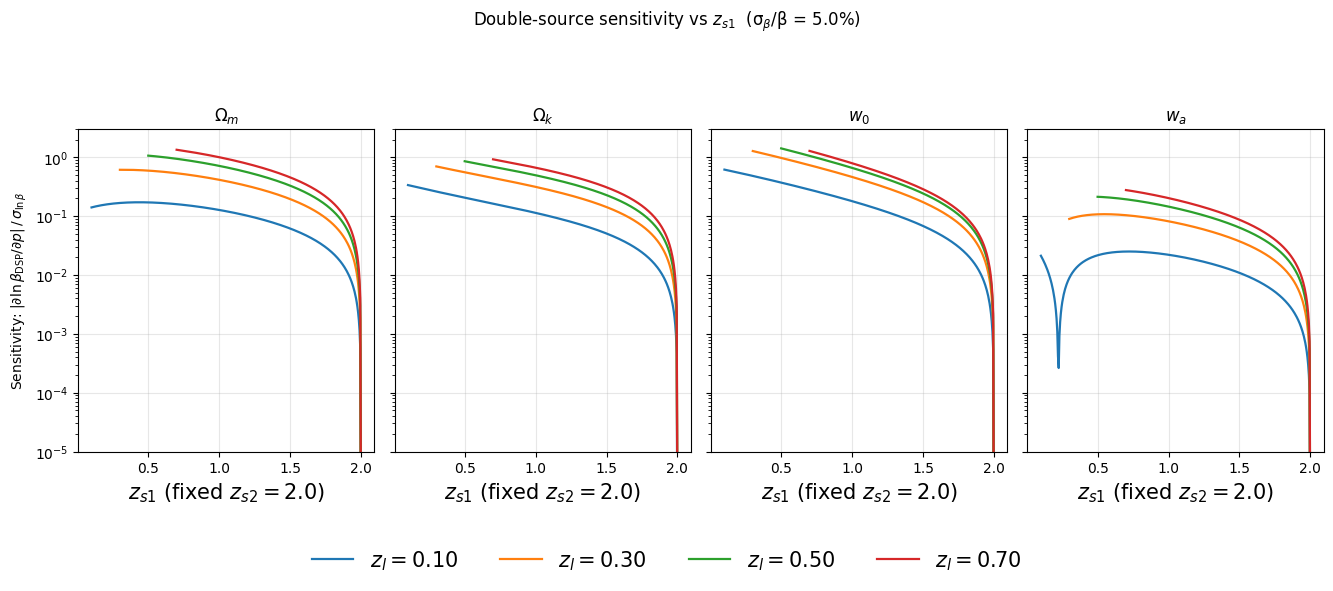

In [68]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sensitivity_beta_vs_zs1_tripanel(
    zl_list, zs2_fixed, cosmo_cpl, outputname,
    sigma_frac=0.05, npts=300, eps=1e-6, sharey=False
):
    cosmo = dict(H0=cosmo_cpl.get("H0", 70.0),
                 omega_m=cosmo_cpl.get("omega_m", 0.3),
                 omega_k=cosmo_cpl.get("omega_k", 0.0),
                 w0=cosmo_cpl.get("w0", -1.0),
                 wa=cosmo_cpl.get("wa", 0.0))
    cosmo.pop("w", None)

    params = ["omega_m","omega_k","w0","wa"]
    titles = [r"$\Omega_m$", r"$\Omega_k$", r"$w_0$", r"$w_a$"]

    # 关键：开启 constrained_layout，并且不要再调用 tight_layout()
    fig, axes = plt.subplots(1, 4, figsize=(14, 6), sharey=sharey, constrained_layout=True)

    for ax, p, ttl in zip(axes, params, titles):
        for zl in zl_list:
            if not (zl + eps < zs2_fixed - eps):
                continue
            zs1_lo = zl + eps
            zs1_hi = zs2_fixed - eps
            n_this = max(5, int(npts * max(zs1_hi - zs1_lo, 0.0) / max(zs2_fixed, 1e-8)))
            zs1_grid = np.linspace(zs1_lo, zs1_hi, n_this)

            sens = []
            for zs1 in zs1_grid:
                d = dlnbeta_dp(zl, zs1, zs2_fixed, cosmo, p)
                sens.append(abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan)

            m = np.isfinite(zs1_grid) & np.isfinite(sens)
            if np.any(m):
                ax.plot(zs1_grid[m], np.asarray(sens)[m], lw=1.6, label=fr"$z_l={zl:.2f}$")

        ax.set_yscale('log')
        ax.grid(alpha=0.3)
        ax.set_title(ttl)
        ax.set_xlabel(fr"$z_{{s1}}$ (fixed $z_{{s2}}={zs2_fixed:.1f}$)", fontsize=15)

        # 可选 y-lims
        if p == "omega_m":
            ymin, ymax = ax.get_ylim()
            ax.set_ylim(bottom=0.01, top=max(ymax, 0.5))
        elif p == "w0":
            ax.set_ylim(bottom=0.001)
        elif p == "wa":
            ax.set_ylim(bottom=1e-5)

    axes[0].set_ylabel(r"Sensitivity: $|\partial \ln \beta_{\rm DSP}/\partial p|\,/\,\sigma_{\ln\beta}$")

    fig.suptitle(fr"Double-source sensitivity vs $z_{{s1}}$  (σ$_\beta$/β = {sigma_frac:.1%})",
             y=0.97, fontsize=12)  # y<1，放在画布内
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="lower center", fontsize=15,
                   ncol=min(len(labels), 4), frameon=False)
    
    # 关键：tight_layout 时用 rect 预留上下空间
    fig.tight_layout(rect=[0.02, 0.12, 0.98, 0.9])
    fig.savefig(outputname, dpi=300, bbox_inches='tight', pad_inches=0.2)
    plt.show()
    plt.close(fig)



cosmo_cpl  = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)
zs2_fixed  = 2.0
zl_list    = [0.1, 0.3, 0.5, 0.7]

plot_sensitivity_beta_vs_zs1_tripanel(
    zl_list, zs2_fixed, cosmo_cpl,outputname = r"fisher_double_source01.png",
    sigma_frac=0.05, npts=400, sharey=True
)


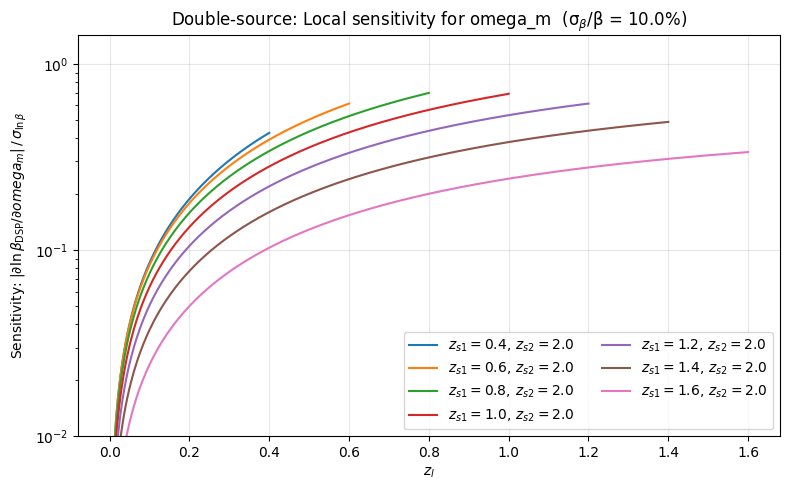

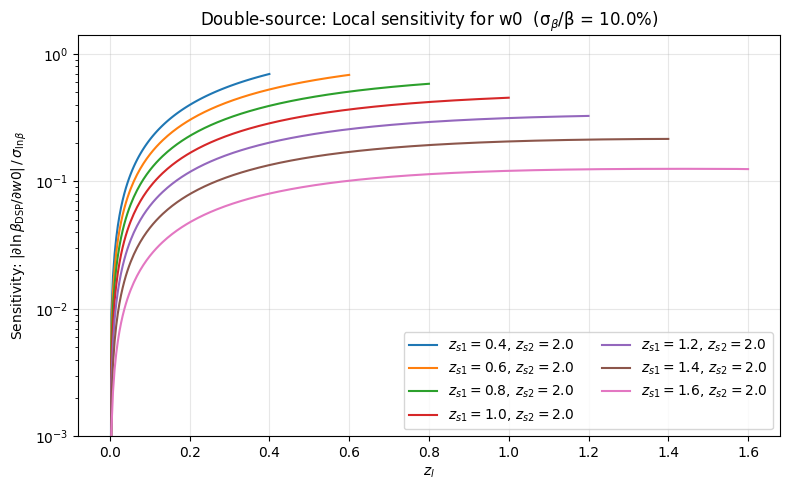

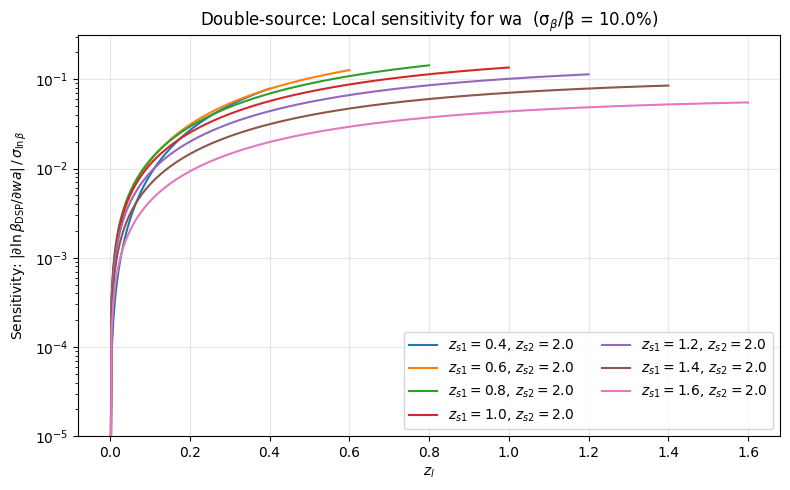

In [33]:
# ---------- 7) 示例调用 ----------
if __name__ == "__main__":
    # 基准宇宙学
    cosmo_wcdm = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w=-1.0)          # wCDM（常数 w）
    cosmo_cpl  = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)  # CPL

    zs2_fixed = 2.0
    zs1_list  = [0.4,0.6, 0.8, 1.0,1.2,1.4, 1.6]
    sigma_frac = 0.1   # 假设 β 的相对观测误差为 5%
    dz = 0.004

    # —— 局部敏感度：对不同参数各画 4 条曲线（对应 4 个 z_s1） ——
    plot_local_sensitivity_beta(zs1_list, zs2_fixed, param="omega_m", cosmo=cosmo_wcdm, sigma_frac=sigma_frac, dz=dz)
    # plot_local_sensitivity_beta(zs1_list, zs2_fixed, param="H0", cosmo=cosmo_wcdm, sigma_frac=sigma_frac, dz=dz)
    # plot_local_sensitivity_beta(zs1_list, zs2_fixed, param="w",        cosmo=cosmo_wcdm, sigma_frac=sigma_frac, dz=dz)
    # 或 CPL：
    plot_local_sensitivity_beta(zs1_list, zs2_fixed, param="w0",       cosmo=cosmo_cpl,  sigma_frac=sigma_frac, dz=dz)
    plot_local_sensitivity_beta(zs1_list, zs2_fixed, param="wa",       cosmo=cosmo_cpl,  sigma_frac=sigma_frac, dz=dz)

    # —— 可选：累积边际化（把某个 z_s1 下所有 z_l 信息相加） ——
    # params = ["omega_m", "w"]          # wCDM
    # plot_cumulative_marginalized_beta(zs1_list, zs2_fixed, params, cosmo_wcdm, sigma_frac=sigma_frac, dz=dz, param_to_plot=None)


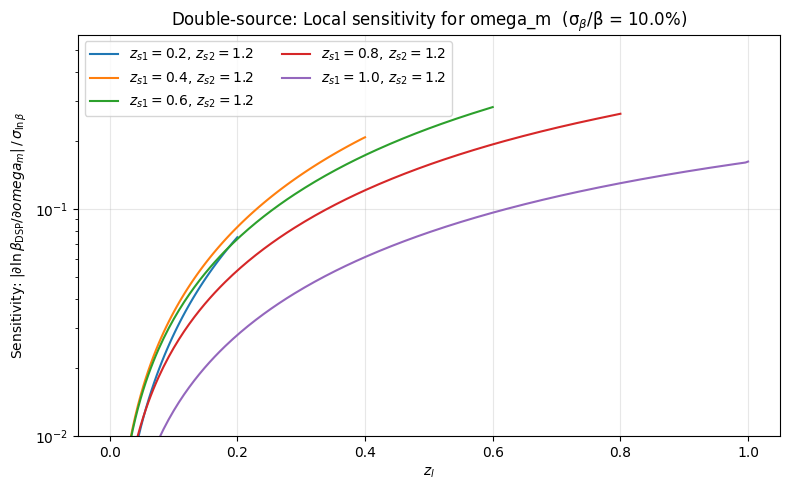

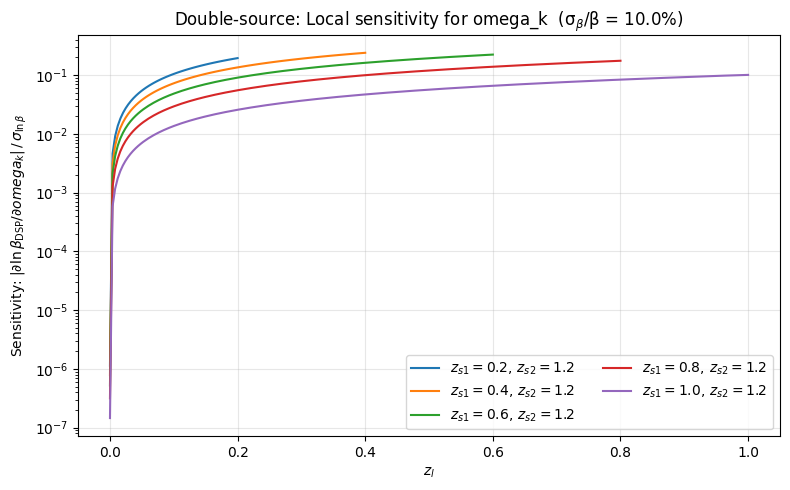

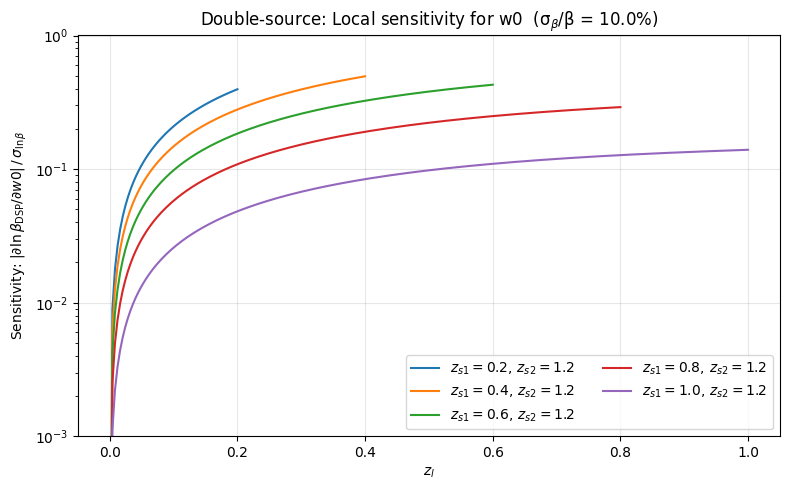

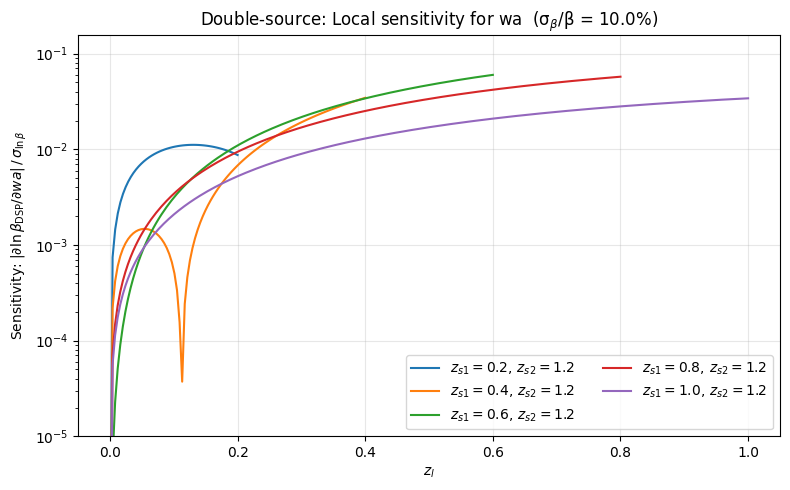

In [56]:
# ---------- 7) 示例调用 ----------
if __name__ == "__main__":
    # 基准宇宙学
    cosmo_wcdm = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w=-1.0)          # wCDM（常数 w）
    cosmo_cpl  = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)  # CPL

    zs2_fixed = 1.2
    zs1_list  = [0.2,0.4,0.6, 0.8, 1.0]
    sigma_frac = 0.1   # 假设 β 的相对观测误差为 5%
    dz = 0.004

    # —— 局部敏感度：对不同参数各画 4 条曲线（对应 4 个 z_s1） ——
    plot_local_sensitivity_beta(zs1_list, zs2_fixed, param="omega_m", cosmo=cosmo_wcdm, sigma_frac=sigma_frac, dz=dz)
    plot_local_sensitivity_beta(zs1_list, zs2_fixed, param="omega_k", cosmo=cosmo_wcdm, sigma_frac=sigma_frac, dz=dz)
    # plot_local_sensitivity_beta(zs1_list, zs2_fixed, param="w",        cosmo=cosmo_wcdm, sigma_frac=sigma_frac, dz=dz)
    # 或 CPL：
    plot_local_sensitivity_beta(zs1_list, zs2_fixed, param="w0",       cosmo=cosmo_cpl,  sigma_frac=sigma_frac, dz=dz)
    plot_local_sensitivity_beta(zs1_list, zs2_fixed, param="wa",       cosmo=cosmo_cpl,  sigma_frac=sigma_frac, dz=dz)

    # —— 可选：累积边际化（把某个 z_s1 下所有 z_l 信息相加） ——
    # params = ["omega_m", "w"]          # wCDM
    # plot_cumulative_marginalized_beta(zs1_list, zs2_fixed, params, cosmo_wcdm, sigma_frac=sigma_frac, dz=dz, param_to_plot=None)


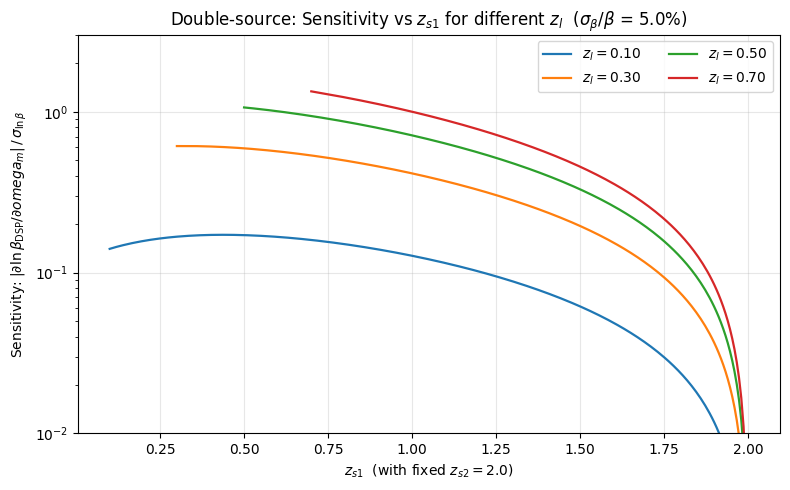

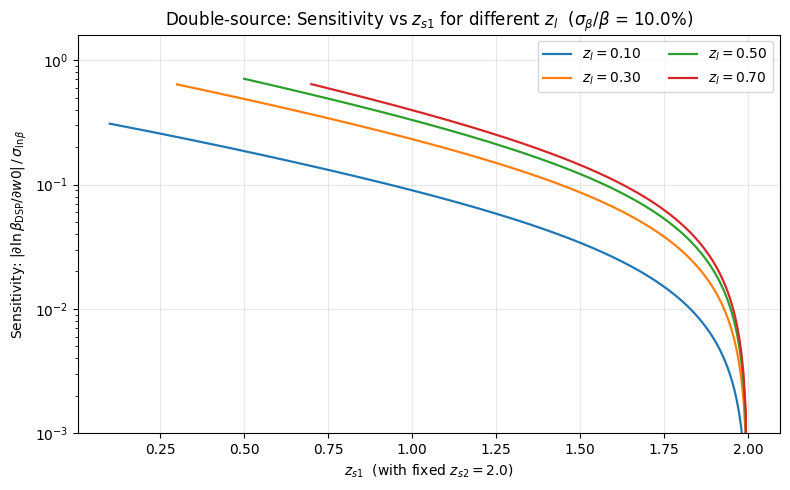

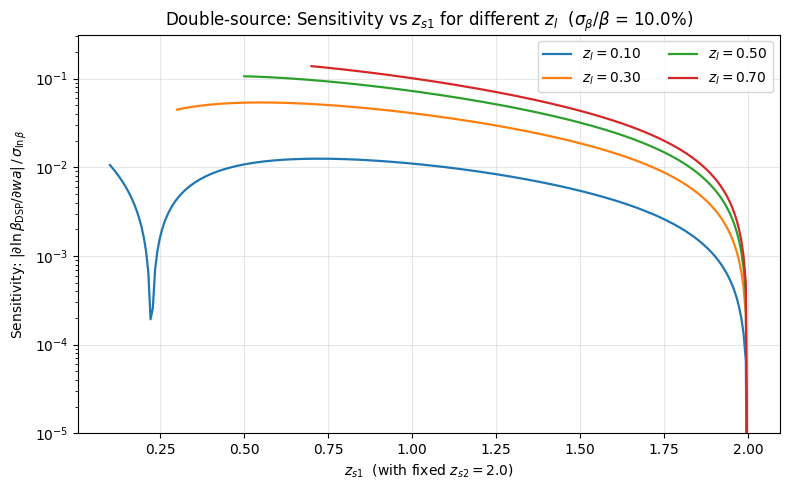

In [49]:
cosmo_wcdm = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w=-1.0)
zs2_fixed = 2.0
zl_list   = [0.1, 0.3, 0.5, 0.7]

plot_sensitivity_beta_vs_zs1(zl_list, zs2_fixed, param="omega_m", cosmo=cosmo_wcdm, sigma_frac=0.05)
# plot_sensitivity_beta_vs_zs1(zl_list, zs2_fixed, param="w",        cosmo=cosmo_wcdm, sigma_frac=0.05)


# If using CPL instead:
cosmo_cpl = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)
plot_sensitivity_beta_vs_zs1(zl_list, zs2_fixed, param="w0",       cosmo=cosmo_cpl,  sigma_frac=0.1)
plot_sensitivity_beta_vs_zs1(zl_list, zs2_fixed, param="wa",       cosmo=cosmo_cpl,  sigma_frac=0.1)


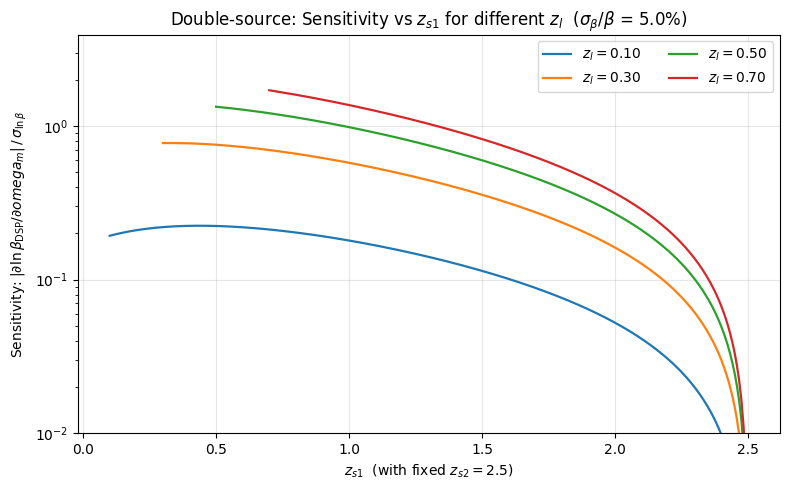

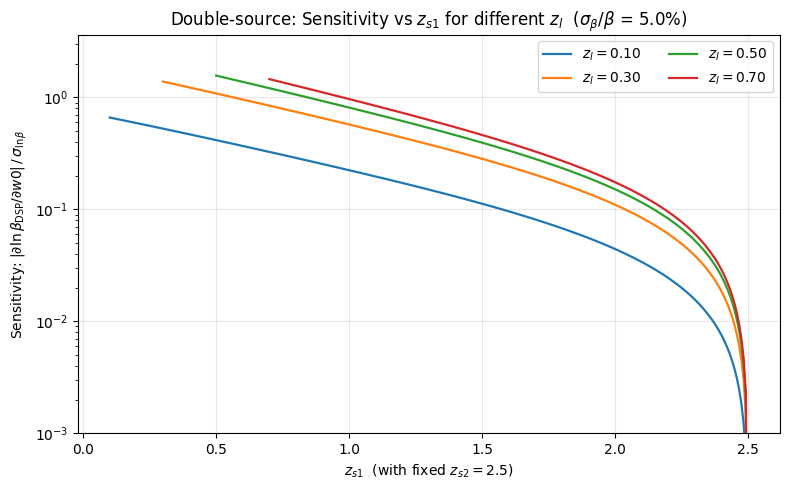

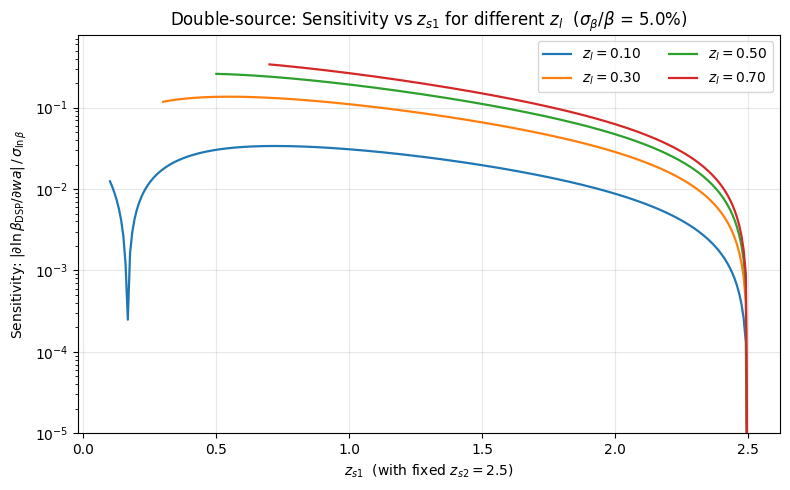

In [52]:
cosmo_wcdm = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w=-1.0)
zs2_fixed = 2.5
zl_list   = [0.1, 0.3, 0.5, 0.7]

plot_sensitivity_beta_vs_zs1(zl_list, zs2_fixed, param="omega_m", cosmo=cosmo_wcdm, sigma_frac=0.05)
# plot_sensitivity_beta_vs_zs1(zl_list, zs2_fixed, param="w",        cosmo=cosmo_wcdm, sigma_frac=0.05)


# If using CPL instead:
cosmo_cpl = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)
plot_sensitivity_beta_vs_zs1(zl_list, zs2_fixed, param="w0",       cosmo=cosmo_cpl,  sigma_frac=0.05)
plot_sensitivity_beta_vs_zs1(zl_list, zs2_fixed, param="wa",       cosmo=cosmo_cpl,  sigma_frac=0.05)


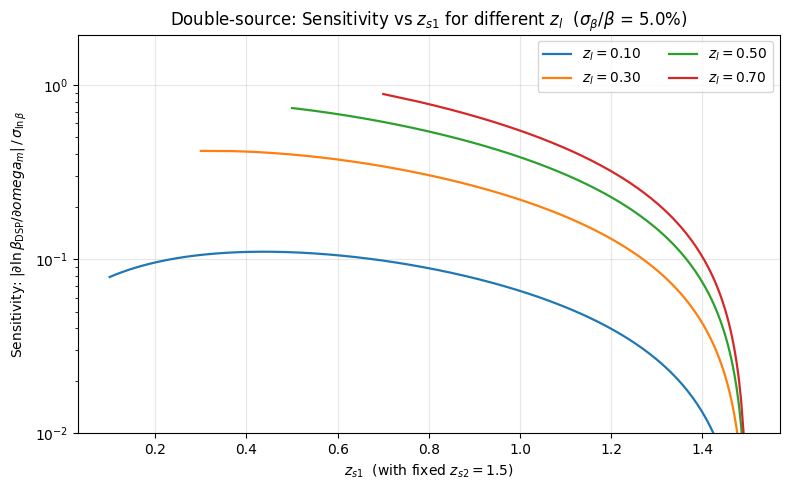

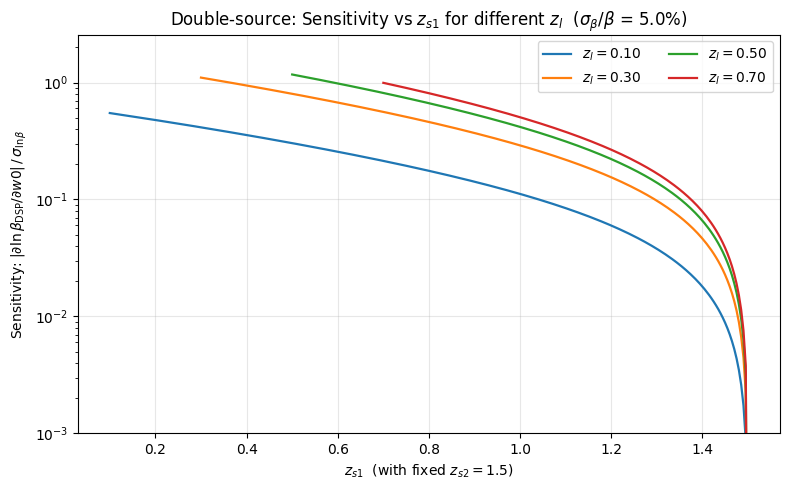

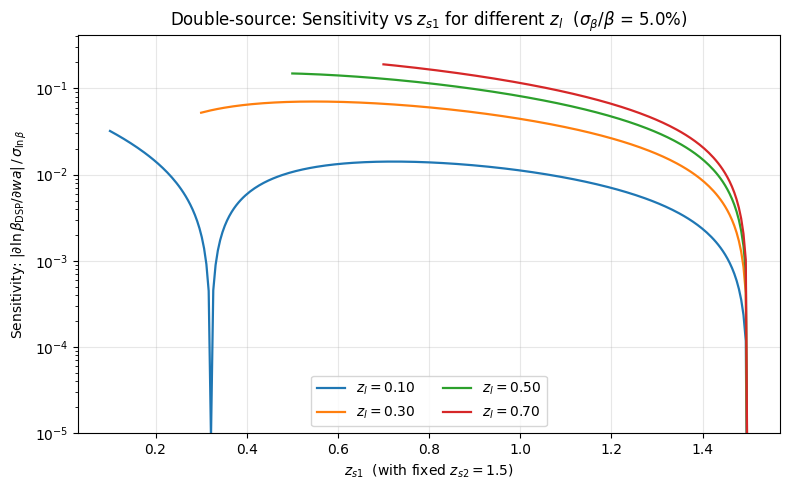

In [53]:
cosmo_wcdm = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w=-1.0)
zs2_fixed = 1.5
zl_list   = [0.1, 0.3, 0.5, 0.7]

plot_sensitivity_beta_vs_zs1(zl_list, zs2_fixed, param="omega_m", cosmo=cosmo_wcdm, sigma_frac=0.05)
# plot_sensitivity_beta_vs_zs1(zl_list, zs2_fixed, param="w",        cosmo=cosmo_wcdm, sigma_frac=0.05)


# If using CPL instead:
cosmo_cpl = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)
plot_sensitivity_beta_vs_zs1(zl_list, zs2_fixed, param="w0",       cosmo=cosmo_cpl,  sigma_frac=0.05)
plot_sensitivity_beta_vs_zs1(zl_list, zs2_fixed, param="wa",       cosmo=cosmo_cpl,  sigma_frac=0.05)


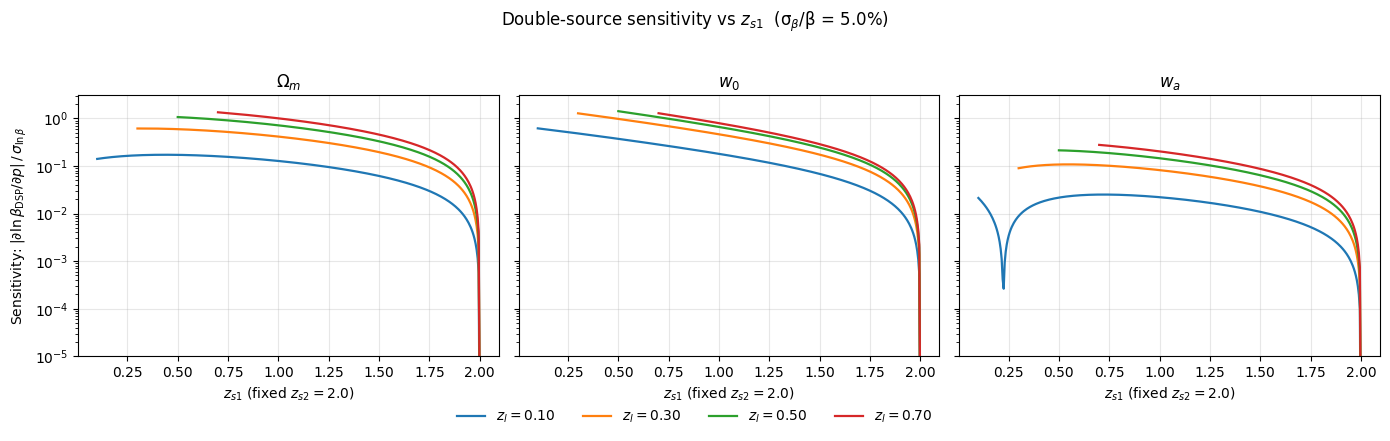

In [55]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sensitivity_beta_vs_zs1_tripanel(
    zl_list, zs2_fixed, cosmo_cpl,
    sigma_frac=0.05, npts=300, eps=1e-6, sharey=False
):
    """
    Triple-panel plot: sensitivity(zs1) for params ['omega_m','w0','wa'].
    Each panel shows curves for different z_l in zl_list, with zs1 swept from (zl+eps) to (zs2_fixed-eps).
    Args:
        zl_list    : iterable of lens redshifts.
        zs2_fixed  : scalar, fixed source-2 redshift.
        cosmo_cpl  : dict cosmology for CPL (must include omega_m, w0, wa; omega_k optional).
        sigma_frac : fractional uncertainty on β (σ_β / β).
        npts       : number of zs1 samples per curve.
        eps        : small padding away from endpoints.
        sharey     : if True, subplots share the y-axis limits.
    """
    # Ensure CPL keys exist
    cosmo = dict(H0=cosmo_cpl.get("H0", 70.0),
                 omega_m=cosmo_cpl.get("omega_m", 0.3),
                 omega_k=cosmo_cpl.get("omega_k", 0.0),
                 w0=cosmo_cpl.get("w0", -1.0),
                 wa=cosmo_cpl.get("wa", 0.0))
    # Make sure 'w' isn't set (we want CPL)
    if "w" in cosmo:
        cosmo.pop("w", None)

    params = ["omega_m", "w0", "wa"]
    titles = [r"$\Omega_m$", r"$w_0$", r"$w_a$"]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=sharey)
    for ax, p, ttl in zip(axes, params, titles):
        for zl in zl_list:
            if not (zl + eps < zs2_fixed - eps):
                continue
            zs1_lo = zl + eps
            zs1_hi = zs2_fixed - eps
            n_this = max(5, int(npts * max(zs1_hi - zs1_lo, 0.0) / max(zs2_fixed, 1e-8)))
            zs1_grid = np.linspace(zs1_lo, zs1_hi, n_this)

            sens = []
            for zs1 in zs1_grid:
                d = dlnbeta_dp(zl, zs1, zs2_fixed, cosmo, p)
                sens.append(abs(d) / max(sigma_frac, 1e-30) if np.isfinite(d) else np.nan)

            y = np.asarray(sens, float)
            m = np.isfinite(zs1_grid) & np.isfinite(y)
            if np.any(m):
                ax.plot(zs1_grid[m], y[m], lw=1.6, label=fr"$z_l={zl:.2f}$")

        ax.set_yscale('log')
        ax.grid(alpha=0.3)
        ax.set_title(ttl)
        ax.set_xlabel(fr"$z_{{s1}}$ (fixed $z_{{s2}}={zs2_fixed:.1f}$)")

        # Optional: per-parameter y-limits to match your earlier styling
        ymin, ymax = ax.get_ylim()
        if p == "omega_m":
            ax.set_ylim(bottom=0.01, top=max(ymax, 0.5))
        elif p == "w0":
            ax.set_ylim(bottom=0.001)
        elif p == "wa":
            ax.set_ylim(bottom=1e-5)

    axes[0].set_ylabel(r"Sensitivity: $|\partial \ln \beta_{\rm DSP}/\partial p|\,/\,\sigma_{\ln\beta}$")

    # Single legend (from the first axis) placed outside
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="lower center",
                   ncol=min(len(labels), 4), frameon=False, bbox_to_anchor=(0.5, -0.05))

    # FIX: use f-string and escape LaTeX braces
    fig.suptitle(
        fr"Double-source sensitivity vs $z_{{s1}}$  (σ$_\beta$/β = {sigma_frac:.1%})",
        y=1.02, fontsize=12
    )
    fig.tight_layout()
    plt.show()


cosmo_cpl  = dict(H0=70.0, omega_m=0.3, omega_k=0.0, w0=-1.0, wa=0.0)
zs2_fixed  = 2.0
zl_list    = [0.1, 0.3, 0.5, 0.7]

plot_sensitivity_beta_vs_zs1_tripanel(
    zl_list, zs2_fixed, cosmo_cpl,
    sigma_frac=0.05, npts=400, sharey=True
)
